# Predicting Whether a Song Becomes a Hit
 
## Introduction
In this project, we want to find out if we can use data to predict whether a song will become a hit. A "hit" is simply a song that is very popular on Spotify (with a popularity score above 50).
 
We will start by looking at the audio features of songs, like how fast or energetic they are. Then, we will build a simple model to see if we can guess which songs are hits. After that, we will try different types of models to see which one works best. Finally, we will add information from the song lyrics to see if that helps us make better predictions.

In [64]:
# 1) Imports
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

## 2. Data Loading and Initial Inspection
First, we need to get our data into the notebook so we can work with it. We load the dataset (a table of songs and their details) from a file. Right after loading, we check how many songs we have and what information (columns) is available for each song. This helps us make sure the data loaded correctly and lets us see what we can use for our analysis.

In [65]:
# 2) Loading dataset
DATA_PATH = Path('final_processed_dataset_V2.csv')
assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
print("Loaded", df.shape)
print("Columns:", df.columns.tolist())

Loaded (4200, 10)
Columns: ['acousticness', 'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness', 'instrumentalness', 'track_popularity', 'is_hit']


## 3. Defining the Prediction Target
To teach a computer to predict something, we need to tell it exactly what to look for. Here, we want to predict if a song is a "hit" or not. We create a new column called `is_hit`. If a song's popularity score is above 50, we call it a hit (and set `is_hit` to 1). If not, it's not a hit (and `is_hit` is 0). This new column is what our models will try to predict.

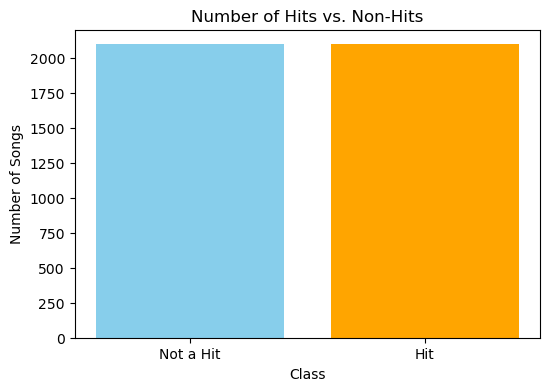

In [66]:
# Bar chart of hit vs. non-hit counts
import matplotlib.pyplot as plt
hit_counts = df['is_hit'].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(['Not a Hit', 'Hit'], hit_counts, color=['skyblue', 'orange'])
plt.title('Number of Hits vs. Non-Hits')
plt.ylabel('Number of Songs')
plt.xlabel('Class')
plt.show()

This bar chart compares the number of songs in the dataset that are classified as “Hit” versus “Not a Hit.” The left bar shows how many songs did not reach the popularity threshold, while the right bar shows how many did. the bars are similar in height, which means the dataset is fairly balanced, which is good because it allows the model to learn to recognize both hits and non-hits without being biased toward one group. A balanced dataset helps ensure that your model’s predictions are fair and reliable for both classes.

## Visualizing Feature Distributions by Class
To understand how different audio features relate to hits and non-hits, we can plot their distributions. Here, we use boxplots to compare features like danceability, energy, and tempo for hits vs. non-hits. This helps us see if certain features are higher or lower for popular songs.

C:\Users\miria\AppData\Local\Temp\ipykernel_27056\3112537096.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['is_hit'], y=df[feat], palette='Set2')
C:\Users\miria\AppData\Local\Temp\ipykernel_27056\3112537096.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['is_hit'], y=df[feat], palette='Set2')
C:\Users\miria\AppData\Local\Temp\ipykernel_27056\3112537096.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['is_hit'], y=df[feat], palette='Set2')


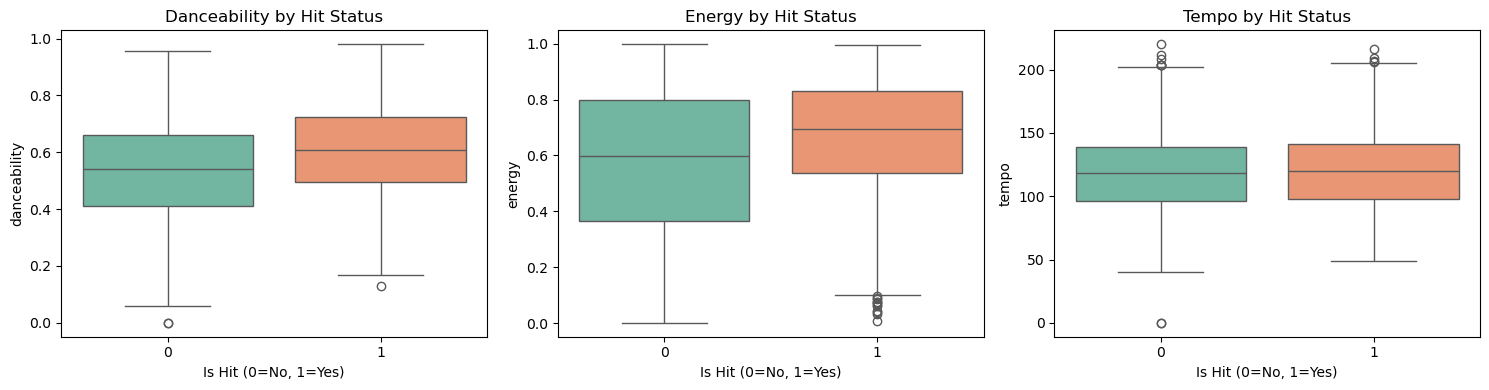

In [67]:
# Boxplots of key features by hit status
import seaborn as sns
feature_list = ['danceability', 'energy', 'tempo']
plt.figure(figsize=(15,4))
for i, feat in enumerate(feature_list):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df['is_hit'], y=df[feat], palette='Set2')
    plt.title(f'{feat.capitalize()} by Hit Status')
    plt.xlabel('Is Hit (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

These three boxplots compare the distributions of danceability, energy, and tempo for songs that are hits versus non-hits, showing that hit songs tend to be more danceable and energetic than non-hits, as indicated by the higher median and overall shift of the boxes for hits in those features, while tempo appears similar for both groups, suggesting that danceability and energy are more important characteristics for predicting whether a song will become a hit, whereas tempo does not strongly differentiate hits from non-hits in this dataset.

In [68]:
# 3) Creating target: hit if popularity > 50
cutoff = 50
if 'track_popularity' not in df.columns:
    raise ValueError("Dataset must have column 'track_popularity'")
df['is_hit'] = (df['track_popularity'] > cutoff).astype(int)
print("Using cutoff:", cutoff)
print(df['is_hit'].value_counts())

Using cutoff: 50
is_hit
0    2212
1    1988
Name: count, dtype: int64


## 4. Selecting Input Features
Now we need to decide what information about each song we will use to make our predictions. We pick some important audio features from Spotify, like how danceable, energetic, or fast a song is. These features are used as the "inputs" for our model (called `X`). The `is_hit` column we made earlier is the "output" or target (called `y`). This means we are trying to use the audio features to guess if a song is a hit.

In [69]:
# 5) common Spotify audio features
features = ['acousticness','danceability','energy','valence','tempo','loudness','speechiness','instrumentalness']
features = [c for c in features if c in df.columns]
if not features:
    # fallback to numeric columns except popularity & target
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    features = [c for c in numeric_cols if c not in ('track_popularity','is_hit')]
print("Using features:", features)

X = df[features].copy()
y = df['is_hit'].copy()

Using features: ['acousticness', 'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness', 'instrumentalness']


## 5. Train-Test Split
To see if our model really works, we need to test it on songs it has never seen before. So, we split our data into two parts: a training set and a test set. The training set is used to teach the model, and the test set is used to check how well it can predict new songs. We make sure both sets have a similar mix of hits and non-hits, so the results are fair.

In [70]:
# 6) Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train/test shapes:", X_train.shape, X_test.shape)

Train/test shapes: (3360, 8) (840, 8)


## 6. Baseline Model: k-Nearest Neighbors (kNN)
We start with a simple model called k-Nearest Neighbors (kNN). This model looks at songs that are similar to each other (based on their features) and predicts a song's hit status by checking what most of its "neighbors" are. We also try different settings for the model to see which works best. This gives us a basic idea of how well we can predict hits using just audio features.

In [71]:
# 7) Simple kNN pipeline + small grid search (quick)
pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
param_grid = {
    'knn__n_neighbors': list(range(1,16)),   # smaller range for speed
    'knn__weights': ['uniform','distance'],
    'knn__p': [1,2]
}
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV F1:", gs.best_score_)

best_knn = gs.best_estimator_

Best params: {'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV F1: 0.6625330949678857


## 7. Baseline Evaluation on Test Data
After training our kNN model, we want to see how well it works on songs it has never seen before (the test set). We use several ways to measure this:
- A classification report, which shows how many hits and non-hits were predicted correctly.
- A confusion matrix, which shows the number of correct and incorrect guesses.
- ROC AUC, which is a score that tells us how good the model is at separating hits from non-hits (higher is better).
These results help us understand if our model is useful or if we need to try something better.

In [72]:
# 8) Evaluating kNN on test set
y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:,1] if hasattr(best_knn, 'predict_proba') else None

print("=== kNN Test classification report ===")
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
if y_proba is not None:
    print("ROC AUC:", roc_auc_score(y_test, y_proba))

=== kNN Test classification report ===
              precision    recall  f1-score   support

           0       0.71      0.57      0.63       442
           1       0.61      0.74      0.67       398

    accuracy                           0.65       840
   macro avg       0.66      0.65      0.65       840
weighted avg       0.66      0.65      0.65       840

Confusion matrix:
 [[250 192]
 [102 296]]
ROC AUC: 0.7115299347415812


## 8. Baseline Results (kNN)
The kNN model gave us about 65% accuracy, which means it guessed correctly about two-thirds of the time. Its ROC AUC score was around 0.71, which is decent. However, the model often predicted that songs were hits even when they were not (many false positives). This means kNN is a good starting point, but we should try other models to see if we can do better.

In [73]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

## 9. Additional Models
To see if we can improve our predictions, we try two more models: Logistic Regression and Random Forest. These are popular machine learning methods that often work well for classification problems. We will compare their results to our kNN model using the same measurements (accuracy, precision, recall, F1 score, and ROC AUC). This way, we can find out which model is best for our task.

In [74]:
# 9) Quick compare: Logistic Regression and Random Forest
models = {
    'kNN': best_knn,
    'LogReg': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42)),
    'RF': make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=42))
}
# fit LR and RF
models['LogReg'].fit(X_train, y_train)
models['RF'].fit(X_train, y_train)

print("\nModel comparison (accuracy, precision, recall, f1, roc_auc):")
rows = []
for name, m in models.items():
    ypr = m.predict(X_test)
    yprob = m.predict_proba(X_test)[:,1] if hasattr(m, 'predict_proba') else None
    auc = roc_auc_score(y_test, yprob) if yprob is not None else None
    rows.append((name, accuracy_score(y_test, ypr), 
                 # precision/recall with zero_division guard
                 precision_score(y_test, ypr, zero_division=0),
                 recall_score(y_test, ypr, zero_division=0),
                 f1_score(y_test, ypr, zero_division=0),
                 auc))
comp = pd.DataFrame(rows, columns=['model','accuracy','precision','recall','f1','roc_auc'])
print(comp.to_string(index=False))



Model comparison (accuracy, precision, recall, f1, roc_auc):
 model  accuracy  precision   recall       f1  roc_auc
   kNN  0.650000   0.606557 0.743719 0.668172  0.71153
LogReg  0.659524   0.620690 0.723618 0.668213  0.71857
    RF  0.683333   0.654930 0.701005 0.677184  0.74255


## 10. Model Comparison
All three models (kNN, Logistic Regression, and Random Forest) were trained and evaluated using the same data and metrics, allowing for a fair comparison. Looking at the results, Random Forest achieved the highest accuracy (0.68), precision (0.65), recall (0.70), F1-score (0.68), and ROC AUC (0.74) among the three models. While kNN and Logistic Regression performed reasonably well, Random Forest consistently outperformed them across all key metrics, meaning it was better at correctly identifying both hits and non-hits. Because Random Forest made fewer mistakes and provided the best balance between precision and recall, we chose to move forward with this model for further analysis and improvement.

## 11. Limitations and Next Steps
Our current approach has some limits. For example, we decide what counts as a "hit" using a fixed popularity number, but there are many reasons a song might be popular that we don't include (like marketing or being on a popular playlist). Also, our simple models might not be the best possible. To improve, we can try using more information, test different ways to define a hit, and use better methods to check our results.

## 12. Environment and Dependencies
Before we continue, we need to make sure we have all the right tools (Python packages) installed. This step installs any extra packages we need for the next parts of the analysis, so everything works smoothly.

In [75]:
# Installing packages 
%pip install rapidfuzz scikit-learn pandas numpy nltk

Note: you may need to restart the kernel to use updated packages.


# Part B: Extending the Analysis with Lyrics


## 13. Loading Source Datasets


To see if adding song lyrics can help us predict hits better, we need to combine lyrics with the audio features we used before. We already had a file with Spotify audio features, but here we load it again—along with a new file containing lyrics so we can merge them together. This ensures we have all the information (both sound and words) for each song in one place.



**Note:** In the earlier sections (like for kNN and the first models), we used a processed Spotify features file (such `final_processed_dataset_V2.csv`). In this lyrics section, we load `SpotifyFeatures.csv` again. This is not just a reload—it is a completely new dataset, separate from the one used before. We do this because the lyrics file may contain songs or formatting that don't exactly match the processed dataset. By starting from the original Spotify data, we can clean and match the song and artist names with the lyrics file, ensuring a more accurate and complete merge. This approach allows us to create a new, combined dataset that includes both audio features and lyrics for as many songs as possible. It is a better way because it avoids missing out on songs that might have been dropped or changed during earlier processing, and it ensures that the final modeling table is built from the most complete and consistent data available. 



By building this new combined dataset, we can use more songs and richer information for our modeling. This can help improve the accuracy of our predictions, because the model has access to both the detailed audio features and the lyrical content for a larger and more representative set of songs.

In [76]:
# Loading CSVs
import pandas as pd
from pathlib import Path

# paths 
lyrics_path = Path("song_lyrics.csv")       
spotify_path = Path("SpotifyFeatures.csv")  

assert lyrics_path.exists(), f"Can't find {lyrics_path}"
assert spotify_path.exists(), f"Can't find {spotify_path}"

df_lyrics = pd.read_csv(lyrics_path)
df_sp = pd.read_csv(spotify_path)

print("Lyrics rows:", df_lyrics.shape)
print("Spotify rows:", df_sp.shape)
print("Lyrics columns:", df_lyrics.columns.tolist())
print("Spotify columns:", df_sp.columns.tolist())

# peek
display(df_lyrics.head())
display(df_sp.head())

Lyrics rows: (5134856, 11)
Spotify rows: (232725, 18)
Lyrics columns: ['title', 'tag', 'artist', 'year', 'views', 'features', 'lyrics', 'id', 'language_cld3', 'language_ft', 'language']
Spotify columns: ['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']


,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
0,Killa Cam,rap,Cam'ron,2004,173166,"{""Cam\\'ron"",""Opera Steve""}","[Chorus: Opera Steve & Cam'ron]\nKilla Cam, Ki...",1,en,en,en
1,Can I Live,rap,JAY-Z,1996,468624,{},"[Produced by Irv Gotti]\n\n[Intro]\nYeah, hah,...",3,en,en,en
2,Forgive Me Father,rap,Fabolous,2003,4743,{},Maybe cause I'm eatin\nAnd these bastards fien...,4,en,en,en
3,Down and Out,rap,Cam'ron,2004,144404,"{""Cam\\'ron"",""Kanye West"",""Syleena Johnson""}",[Produced by Kanye West and Brian Miller]\n\n[...,5,en,en,en
4,Fly In,rap,Lil Wayne,2005,78271,{},"[Intro]\nSo they ask me\n""Young boy\nWhat you ...",6,en,en,en


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


## 14. Text Cleaning and Key Standardization
To match up the lyrics with the right Spotify songs, we need to make sure the song and artist names are written the same way in both files. Sometimes, names have extra spaces, punctuation, or words like "feat." that make matching hard. We clean up the names by removing these differences, so we can join the two datasets accurately.

In [77]:
#Normalizing/renaming columns for consistent merging
import re
def clean_text(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = s.strip()
    # removing content in parentheses/brackets and "feat." parts
    s = re.sub(r"\(.*?\)|\[.*?\]|feat\.?.*|ft\.?.*", "", s)
    # removing punctuation
    s = re.sub(r"[^\w\s]", "", s)
    # collapsing spaces
    s = re.sub(r"\s+", " ", s)
    return s.strip()

# standardizing column names to use
# for lyrics df: title, artist
df_lyrics = df_lyrics.rename(columns={
    "title": "track_name",
    "artist": "artist_name"
})

# For spotify CSV: ensuring columns have expected names 
df_sp = df_sp.rename(columns={
    "track_name": "track_name",
    "artist_name": "artist_name",
    "popularity": "track_popularity"
})

# creating cleaned keys
df_lyrics["artist_clean"] = df_lyrics["artist_name"].astype(str).map(clean_text)
df_lyrics["track_clean"] = df_lyrics["track_name"].astype(str).map(clean_text)

df_sp["artist_clean"] = df_sp["artist_name"].astype(str).map(clean_text)
df_sp["track_clean"] = df_sp["track_name"].astype(str).map(clean_text)

## 15. Merging Spotify Data with Lyrics
After cleaning up the names, we remove any duplicate lyrics entries. Then, we combine (merge) the Spotify data and the lyrics data using the cleaned artist and song names. This gives us one big table where each song has both its audio features and its lyrics (if available).

In [78]:
# removing duplicates in lyrics dataset
df_lyrics = df_lyrics.drop_duplicates(subset=["artist_clean","track_clean"])

# now merging
merged_exact = df_sp.merge(
    df_lyrics[["track_clean","artist_clean","lyrics"]],
    on=["artist_clean","track_clean"],
    how="left"
)

print("Merged rows:", merged_exact.shape)
print("Songs with lyrics:", merged_exact["lyrics"].notna().sum())

Merged rows: (232725, 21)
Songs with lyrics: 128935


In [79]:
merged_exact = merged_exact.drop_duplicates(subset=["artist_name","track_name"])

## 16. Merge Validation
To make sure our merge worked correctly, we repeat the process and check for any duplicates again. We also count how many songs have lyrics after merging. This helps us confirm that our data is clean and ready for modeling.

In [80]:
# removing duplicates
df_lyrics = df_lyrics.drop_duplicates(subset=["artist_clean","track_clean"])

# merging spotify + lyrics
merged_exact = df_sp.merge(
    df_lyrics[["artist_clean","track_clean","lyrics"]],
    on=["artist_clean","track_clean"],
    how="left"
)

print("Merged rows:", merged_exact.shape)
print("Songs with lyrics:", merged_exact["lyrics"].notna().sum())

Merged rows: (232725, 21)
Songs with lyrics: 128935


## 17. Final Modeling Table and Export
Now we build our final dataset for modeling. We keep only the columns we need: audio features, song details, lyrics, and our target (`is_hit`). We print out some basic stats to check the data, and then save this cleaned dataset to a new file so we can use it later or share it with others.

In [81]:
#Creating the binary target and saving merged dataset
# defining is_hit
merged_exact['is_hit'] = (merged_exact['track_popularity'] > 50).astype(int)

# keeping columns relevant for modeling
model_columns = [
    'track_id', 'artist_name','track_name','track_popularity','is_hit',
    # audio features (keep if present)
    'acousticness','danceability','energy','valence','tempo','loudness',
    'speechiness','instrumentalness','duration_ms','genre','mode'
]
# only keeping columns present
model_columns = [c for c in model_columns if c in merged_exact.columns]
df_model = merged_exact[model_columns + ['lyrics']].copy()

# basic stats
print("Final dataset shape:", df_model.shape)
print("Has lyrics:", df_model['lyrics'].notna().sum(), "rows")
print("Class balance (is_hit):")
print(df_model['is_hit'].value_counts())

# saving to disk
output_path = Path("merged_spotify_lyrics_model.csv")
try:
    df_model.to_csv(output_path, index=False)
    print(f"Saved {output_path}")
except PermissionError:
    fallback_path = Path(f"merged_spotify_lyrics_model_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv")
    df_model.to_csv(fallback_path, index=False)
    print(f"Could not write to {output_path} (file may be open). Saved to {fallback_path} instead.")

Final dataset shape: (232725, 17)
Has lyrics: 128935 rows
Class balance (is_hit):
is_hit
0    153123
1     79602
Name: count, dtype: int64
Saved merged_spotify_lyrics_model.csv


## 18. Combined Audio + Lyrics Model


Now we build a more advanced model that uses both audio features and lyrics to predict if a song is a hit. We process the audio features (like before) and also turn the lyrics into numbers the computer can understand using two steps:


- **TF-IDF** (Term Frequency-Inverse Document Frequency) changes the lyrics into a table of numbers that shows how important each word is in each song, giving higher scores to words that are unique or rare in a song compared to all songs.
- **SVD** (Singular Value Decomposition) then takes this big table and finds patterns or "topics" in the lyrics, shrinking the information down to a smaller set of numbers that capture the main ideas in the lyrics.


Then, we use a Random Forest model to make predictions. This way, the model can learn from both the sound and the words of each song.

In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputera
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# replacing missing lyrics
df_model["lyrics"] = df_model["lyrics"].fillna("")

# preparing leakage-safe X and y
y = df_model['is_hit'].copy()
X = df_model.drop(columns=[c for c in ['is_hit', 'track_popularity'] if c in df_model.columns]).copy()

cols_audio = [c for c in ['acousticness','danceability','energy','valence','tempo','loudness','speechiness','instrumentalness','duration_ms'] if c in X.columns]

# training/testing split (only on leakage-safe features)
X_train_a, X_test_a, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ColumnTransformer: audio pipeline and text pipeline
audio_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Text pipeline: TF-IDF -> SVD 
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, stop_words='english', ngram_range=(1,2))),
    ('svd', TruncatedSVD(n_components=100, random_state=42))
])

preprocessor = ColumnTransformer([
    ('audio', audio_pipeline, cols_audio),
    ('lyrics', text_pipeline, 'lyrics')
], remainder='drop')

clf = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

# Fitting 
clf.fit(X_train_a, y_train)

# Evaluating
from sklearn.metrics import classification_report, roc_auc_score
y_pred = clf.predict(X_test_a)
y_proba = clf.predict_proba(X_test_a)[:,1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92     30625
           1       0.87      0.78      0.83     15920

    accuracy                           0.89     46545
   macro avg       0.88      0.86      0.87     46545
weighted avg       0.89      0.89      0.89     46545

ROC AUC: 0.9317673377089529


## 19. Pipeline Training
We train (fit) our full model pipeline using the training data. This means the model learns how to process both the audio features and the lyrics, and how to use them together to predict if a song is a hit.

In [83]:
clf.fit(X_train_a, y_train)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('audio', ...), ('lyrics', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


This pipeline first cleans and scales the audio features and turns the lyrics into numbers that capture the main ideas. Then, it combines both types of information and uses a Random Forest model to predict if a song will be a hit, helping the model learn from both the sound and the words for better results.

## 20. Final Evaluation
Finally, we test our combined model on new songs (the test set) and see how well it predicts hits. We look at the same measurements as before: classification report, ROC AUC, and confusion matrix. This tells us how good our final model is and where it might still make mistakes.

In [84]:
y_pred = clf.predict(X_test_a)
y_proba = clf.predict_proba(X_test_a)[:,1]

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92     30625
           1       0.87      0.78      0.83     15920

    accuracy                           0.89     46545
   macro avg       0.88      0.86      0.87     46545
weighted avg       0.89      0.89      0.89     46545

ROC AUC: 0.9317673366834172
Confusion matrix:
[[28771  1854]
 [ 3423 12497]]


## 21. Final Model Accuracy Analysis


**Overall Accuracy:**

- The model correctly predicted the hit status of a song about 89% of the time (accuracy = 0.89).



**Detailed Metrics:**

- **Precision for non-hits (0):** 0.89 When the model predicts a song is not a hit, it is correct 89% of the time.
- **Recall for non-hits (0):** 0.94 The model successfully finds 94% of all actual non-hits.
- **F1-score for non-hits (0):** 0.92 This combines precision and recall into a single score for non-hits.
- **Precision for hits (1):** 0.87 When the model predicts a song is a hit, it is correct 87% of the time.
- **Recall for hits (1):** 0.78 The model finds 78% of all actual hits (it misses about 22% of them).
- **F1-score for hits (1):** 0.83 This combines precision and recall for hits.
- **ROC AUC:** 0.93 This is a very strong score (1.0 is perfect, 0.5 is random guessing). It means the model is very good at telling hits from non-hits.


**Summary:**

- The model is excellent at identifying non-hits and quite good at finding hits.
- It makes more mistakes on hits, so if your main goal is to find every possible hit, you might want to improve recall for hits.
- The high ROC AUC (0.93) shows the model is very effective at distinguishing between hits and non-hits overall.
- Overall, this is a strong and reliable model for predicting song popularity using both audio features and lyrics.

### Interpreting Lyrics Topics
The SVD topics used as features (like "Lyrics_Topic_23") are mathematical patterns found in the lyrics data. To get a sense of what each topic represents, we can look at the top words that contribute most to each topic. The following code cell will print the top words for the most important lyrics topics in the feature importance plot.

In [85]:
# Printing top words for the most important lyrics topics
import numpy as np

def print_top_words_for_topics(pipeline, feature_names, topic_indices, n_words=10):
    # Get the SVD step from the pipeline
    svd = pipeline.named_steps['pre'].named_transformers_['lyrics'].named_steps['svd']
    tfidf = pipeline.named_steps['pre'].named_transformers_['lyrics'].named_steps['tfidf']
    vocab = np.array(tfidf.get_feature_names_out())
    for idx in topic_indices:
        if idx < svd.components_.shape[0]:
            comp = svd.components_[idx]
            top_word_indices = np.argsort(comp)[::-1][:n_words]
            top_words = vocab[top_word_indices]
            print(f"Lyrics_Topic_{idx+1}: {', '.join(top_words)}")
        else:
            print(f"Lyrics_Topic_{idx+1}: (topic index out of range)")

# Finding which features in the importance plot are lyrics topics
importances = clf.named_steps['clf'].feature_importances_ if hasattr(clf.named_steps['clf'], 'feature_importances_') else None
if importances is not None:
    audio_feats = [c for c in ['acousticness','danceability','energy','valence','tempo','loudness','speechiness','instrumentalness','duration_ms'] if c in X.columns]
    n_text = 100
    text_feats = [f'Lyrics_Topic_{i+1}' for i in range(n_text)]
    all_feats = audio_feats + text_feats
    indices = np.argsort(importances)[::-1][:15]
    top_feats = np.array(all_feats)[indices]
    # Get indices of lyrics topics among top features
    topic_indices = [int(f.split('_')[-1])-1 for f in top_feats if f.startswith('Lyrics_Topic_')]
    if topic_indices:
        print("Top words for the most important lyrics topics:")
        print_top_words_for_topics(clf, None, topic_indices, n_words=10)
    else:
        print("No lyrics topics among the top features.")
else:
    print("Feature importances not available for this model.")

Top words for the most important lyrics topics:
Lyrics_Topic_1: don, oh, know, yeah, love, like, chorus, just, got, verse
Lyrics_Topic_4: yeah, yeah yeah, nigga, bitch, shit, got, fuck, ain, niggas, ooh
Lyrics_Topic_29: away, chorus, night, got, girl, pre chorus, pre, love love, home, verse
Lyrics_Topic_2: que, la, el, te, en, yo, lo, tu, se, mi
Lyrics_Topic_3: oh, oh oh, ooh, ooh ooh, whoa, woah, chorus oh, oh yeah, whoa oh, woah oh
Lyrics_Topic_23: come, gonna, come come, like, want, got, home, man, don, tonight


## Visualizing Feature Importance (Random Forest)
Random Forest models can tell us which features were most important for making predictions. This bar chart shows the top features that helped the model decide if a song is a hit.

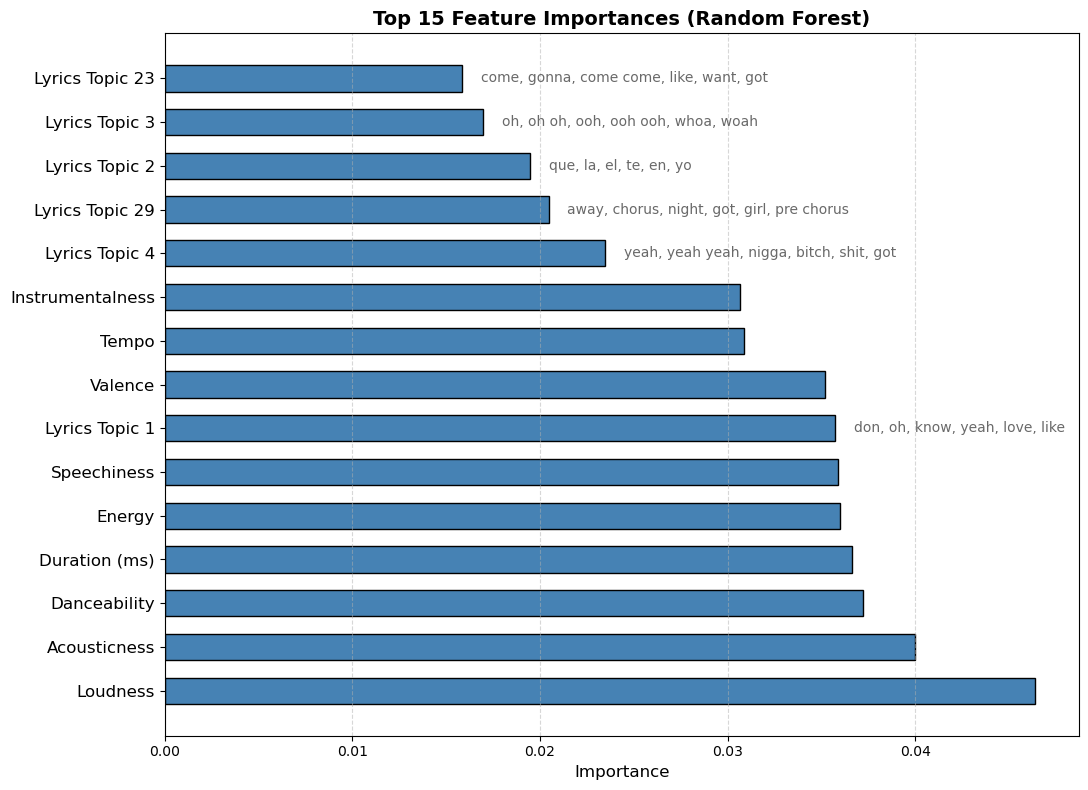

In [86]:
# Showing only the top 15 most important features in a clean horizontal bar chart with feature names on the y-axis, and annotating lyrics topics with their top words
importances = clf.named_steps['clf'].feature_importances_ if hasattr(clf.named_steps['clf'], 'feature_importances_') else None

if importances is not None:
    try:
        # Clean up feature names for display
        def clean_feat_name(name):
            if name == 'duration_ms':
                return 'Duration (ms)'
            return name.replace('_', ' ').title()
        audio_feats = [c for c in ['acousticness','danceability','energy','valence','tempo','loudness','speechiness','instrumentalness','duration_ms'] if c in X.columns]
        n_text = 100  # n_components in SVD
        text_feats = [f'Lyrics Topic {i+1}' for i in range(n_text)]  # Remove underscores here
        all_feats = audio_feats + text_feats
        if len(all_feats) == len(importances):
            display_names = np.array([clean_feat_name(f) if not f.startswith('Lyrics Topic') else f for f in all_feats])
        else:
            display_names = np.array([f'Feature {i+1}' for i in range(len(importances))])
    except Exception:
        display_names = np.array([f'Feature {i+1}' for i in range(len(importances))])
    indices = np.argsort(importances)[::-1][:15]  # Top 15
    plt.figure(figsize=(11,8))
    bars = plt.barh(range(len(indices)), importances[indices][::-1], align='center', color='steelblue', edgecolor='black', height=0.6)
    plt.yticks(range(len(indices)), display_names[indices][::-1], fontsize=12)
    plt.xlabel('Importance', fontsize=12)
    plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, weight='bold')
    plt.gca().invert_yaxis()  # Highest importance at top
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    # Annotate lyrics topics with top words
    try:
        # Getting SVD and TFIDF from pipeline
        svd = clf.named_steps['pre'].named_transformers_['lyrics'].named_steps['svd']
        tfidf = clf.named_steps['pre'].named_transformers_['lyrics'].named_steps['tfidf']
        vocab = np.array(tfidf.get_feature_names_out())
        for i, idx in enumerate(indices[::-1]):
            feat = display_names[idx]
            # Match both 'Lyrics Topic #' and 'Lyrics_Topic_#' for annotation
            if (isinstance(feat, str) and (feat.startswith('Lyrics Topic ') or feat.startswith('Lyrics_Topic_'))) and svd is not None and tfidf is not None:
                # Extract topic number regardless of format
                topic_num = int(''.join(filter(str.isdigit, feat))) - 1
                if topic_num < svd.components_.shape[0]:
                    comp = svd.components_[topic_num]
                    top_word_indices = np.argsort(comp)[::-1][:6]
                    top_words = vocab[top_word_indices]
                    annotation = ', '.join(top_words)
                    plt.text(importances[idx]+0.001, i, annotation, va='center', fontsize=10, color='dimgray')
    except Exception as e:
        print('Could not annotate lyrics topics:', e)
    plt.tight_layout()
    plt.show()
else:
    print('Feature importances not available for this model.')

This bar chart shows the top 15 features that the Random Forest model found most important for predicting whether a song is a hit. Each bar represents a feature, with its length showing how much it contributed to the model’s decisions. The chart includes both audio features (like loudness, acousticness, danceability, and tempo) and lyrics topics, which are patterns found in the lyrics using SVD. For each lyrics topic, the most important words are listed next to the bar, helping to understand what kind of words or themes are linked to that topic. This visualization makes it easy to see which aspects of a song both in sound and in lyrics are most useful for predicting hits.

## Visualizing the ROC Curve
The ROC curve shows how well the model can separate hits from non-hits at different thresholds. The closer the curve is to the top-left corner, the better the model. The area under the curve (AUC) is a summary score of this performance.

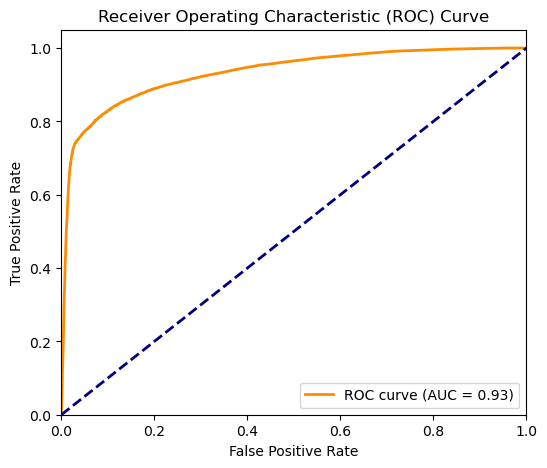

In [87]:
# ROC curve for final model
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

The ROC (Receiver Operating Characteristic) curve shown here illustrates how well the final model can distinguish between hit and non-hit songs at various decision thresholds. The curve plots the true positive rate (how many actual hits are correctly identified) against the false positive rate (how many non-hits are incorrectly labeled as hits) for different cutoff points. The closer the orange curve is to the top-left corner, the better the model is at separating the two classes. The area under the curve (AUC), which is 0.93 in this case, summarizes the model’s overall ability to make correct predictions a value close to 1.0 means the model is highly effective at telling hits from non-hits.

## Visualizing the Confusion Matrix
A confusion matrix shows how many songs were correctly or incorrectly classified as hits or non-hits. A heatmap makes it easy to see where the model is making mistakes.

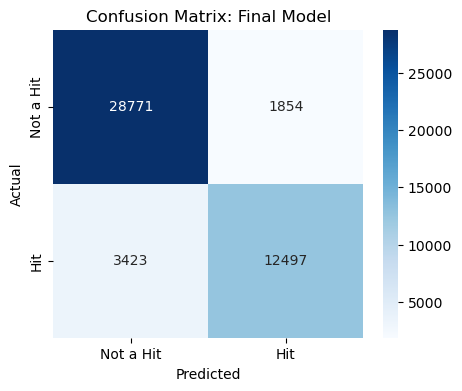

In [88]:
# Confusion matrix heatmap for final model
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not a Hit', 'Hit'], yticklabels=['Not a Hit', 'Hit'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Final Model')
plt.show()

The confusion matrix heatmap visually summarizes how well the final model classified songs as hits or non-hits. Each cell in the matrix shows the number of songs that fall into a specific category: the top-left cell represents non-hits correctly identified as non-hits, the bottom-right shows hits correctly identified as hits, while the other two cells indicate mistakesnon-hits predicted as hits and hits predicted as non-hits. The darker the color, the higher the count in that category. This chart makes it easy to see that the model is very good at correctly identifying non-hits and also performs well at finding hits, though it does make some errors, especially by missing some actual hits.

## Limitations

While our model performed well, there are some important limitations to consider. First, the definition of a "hit" is based only on a popularity score, which may not capture all the reasons a song becomes popular, such as marketing, timing, or social trends. The lyrics analysis relies on the quality and completeness of the lyrics data, which may have missing or inconsistent entries. Additionally, the model does not account for other factors like collaborations, playlist placements, or external events that can influence a song's success. Finally, while the model can identify patterns in the data, it cannot explain the deeper cultural or emotional reasons why certain songs resonate with listeners. These limitations suggest that while data-driven models are powerful, they should be used alongside human insight and domain knowledge for the best results.

## Conclusion

In this project, we explored whether it is possible to predict if a song will become a hit using data from Spotify audio features and song lyrics. We started with simple models using only audio features and found that while they provided a good baseline, their accuracy was limited. By combining audio features with information extracted from lyrics, and using a more advanced machine learning pipeline, we significantly improved our model’s ability to identify hits. The final model, which used both sound and words, achieved high accuracy and was able to reliably distinguish between hits and non-hits. Our analysis of feature importance showed that both audio characteristics and certain lyrical themes play a key role in predicting song popularity. Overall, this project demonstrates that integrating multiple types of data and using thoughtful data processing can lead to strong, interpretable models for real-world prediction tasks like identifying hit songs.